# v3 — Benchmark đa quy mô trên kênh ECG

> Phiên bản có con số đẹp nhất và sai nhiều nhất. Bốn lỗi chồng lên nhau.

| | |
|---|---|
| Kênh tín hiệu | **ECG** ⚠️ (không phải PPG như sản phẩm) |
| Cửa sổ | 30 giây; bước 30 / 10 / 5 / 2.5 giây → chồng 0 / 67 / 83 / 92% ❌ |
| Đặc trưng | 16 cột |
| Làm sạch | IQR ×1.5 trên **toàn bộ** bảng ❌ |
| Chuẩn hóa | StandardScaler fit **toàn bộ** rồi mới chia ❌ |
| Chia dữ liệu | ngẫu nhiên 80/20 ❌ |
| **Điểm công bố** | **98.65% (Stacking) · 98.73% / AUC 0.9998 (RF)** |

## 1. Ý tưởng: nhiều dữ liệu hơn chắc phải tốt hơn

Nếu 1.360 cửa sổ cho 97%, thì nhiều hơn chắc tốt hơn. Nhóm tạo 4 quy mô bằng
cách cho cửa sổ 30 giây **trượt với bước ngắn dần**:

| Bước trượt | Chồng lấn | Số cửa sổ |
|---|---|---|
| 30 giây | 0% | ~1.400 |
| 10 giây | 67% | ~4.100 |
| 5 giây | 83% | ~8.200 |
| 2.5 giây | 92% | ~16.400 |

Chú ý: **lượng tín hiệu gốc không đổi** — vẫn 35 bệnh nhân × 20 phút. Chỉ có
số hàng trong bảng tăng lên, bằng cách cắt chồng lên nhau.

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CWD = os.path.abspath('')
SRC = os.path.dirname(CWD) if os.path.basename(CWD) == 'report' else CWD
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from vlab import store, viz, honest
from vlab.extract import extract_table

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 40)
%matplotlib inline
print('San sang. src =', SRC)


San sang. src = D:\Projects\HealthSense\HealthSense-MachineLearning-Lab\src


In [2]:
import v3
r = store.load('v3')
if r is None:
    r = v3.run()

scale_table = pd.DataFrame(r['scale_table'])
scale_table[['label', 'step_s', 'overlap_pct', 'n_windows']]

,label,step_s,overlap_pct,n_windows
0,không chồng lấn,30.0,0.0,1400
1,chồng 67%,10.0,66.7,4130
2,chồng 83%,5.0,83.3,8225
3,chồng 92%,2.5,91.7,16415


## 2. Vì sao chồng lấn + chia ngẫu nhiên là thảm họa

Với bước 2.5 giây, hai hàng liên tiếp dùng chung **27.5 trên 30 giây** tín
hiệu — gần như là bản sao của nhau.

Chia ngẫu nhiên lúc này không chỉ đặt *cùng bệnh nhân* vào cả hai bên, mà đặt
**gần như chính câu hỏi đó** vào bài giảng. Không còn là "nhớ mặt bệnh nhân"
nữa mà là "đã thấy trước đề thi".

In [3]:
df_92 = extract_table('ECG', 30.0, 2.5, verbose=False)
mot_nguoi = df_92[df_92.record_id == df_92.record_id.iloc[0]].head(3)
print('Ba cửa sổ liên tiếp của cùng một bệnh nhân (bước 2.5 giây):')
display(mot_nguoi[['record_id', 't_start', 'HR_mean', 'SDNN', 'RMSSD', 'SampEn']])

a, b = mot_nguoi.iloc[0], mot_nguoi.iloc[1]
print(f"Cửa sổ 1 bắt đầu ở giây {a['t_start']}, cửa sổ 2 ở giây {b['t_start']}")
print(f"-> hai cửa sổ dùng chung {30 - (b['t_start'] - a['t_start']):.1f}/30 giây tín hiệu")
print(f"   HR_mean: {a['HR_mean']:.2f} vs {b['HR_mean']:.2f}")
print(f"   SDNN   : {a['SDNN']:.2f} vs {b['SDNN']:.2f}")
print('\nHai hàng này gần như giống hệt nhau. Nếu một hàng vào train và hàng')
print('kia vào test, mô hình không cần học gì cả — chỉ cần nhớ lại.')

Ba cửa sổ liên tiếp của cùng một bệnh nhân (bước 2.5 giây):


,record_id,t_start,HR_mean,SDNN,RMSSD,SampEn
0,mimic_perform_af_001,0.0,90.016367,104.859032,159.827814,1.704748
1,mimic_perform_af_001,2.5,91.730923,105.529738,146.957288,1.791759
2,mimic_perform_af_001,5.0,91.077086,102.868614,146.117761,1.446919


Cửa sổ 1 bắt đầu ở giây 0.0, cửa sổ 2 ở giây 2.5
-> hai cửa sổ dùng chung 27.5/30 giây tín hiệu
   HR_mean: 90.02 vs 91.73
   SDNN   : 104.86 vs 105.53

Hai hàng này gần như giống hệt nhau. Nếu một hàng vào train và hàng
kia vào test, mô hình không cần học gì cả — chỉ cần nhớ lại.


## 3. Quy luật: càng chồng lấn, điểm giả càng đẹp

Đây là kết quả quan trọng nhất của notebook này. Chạy cả 4 quy mô, mỗi quy mô
chấm hai lần — cách gốc và LOSO:

,Quy mô,Số cửa sổ,Chấm kiểu cũ,Chấm bằng LOSO,Điểm ảo
0,không chồng lấn,1400,0.9809,0.9079,0.0730
1,chồng 67%,4130,0.9919,0.9199,0.0720
2,chồng 83%,8225,0.9927,0.9195,0.0732
3,chồng 92%,16415,0.9951,0.9198,0.0753


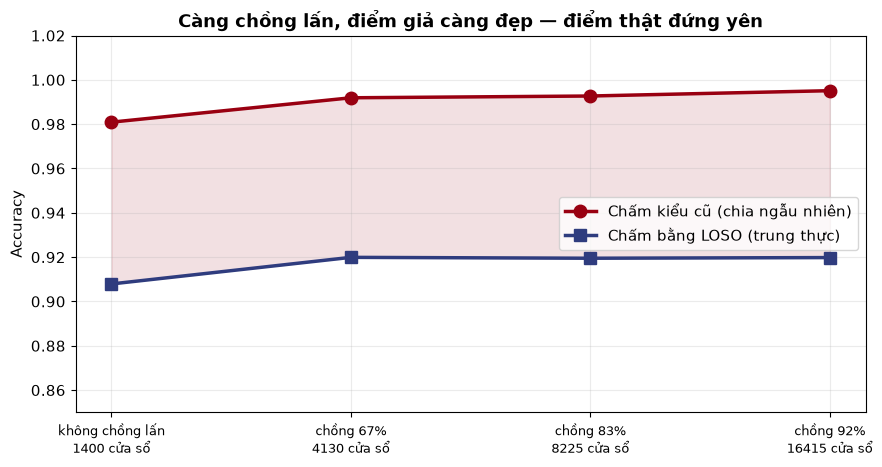

In [4]:
bang = scale_table[['label', 'n_windows', 'leaky_accuracy', 'loso_accuracy', 'inflation']]
bang.columns = ['Quy mô', 'Số cửa sổ', 'Chấm kiểu cũ', 'Chấm bằng LOSO', 'Điểm ảo']
display(bang)

fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(scale_table))
ax.plot(x, scale_table['leaky_accuracy'], 'o-', color=viz.CHERRY, linewidth=2.5,
        markersize=9, label='Chấm kiểu cũ (chia ngẫu nhiên)')
ax.plot(x, scale_table['loso_accuracy'], 's-', color=viz.NAVY, linewidth=2.5,
        markersize=9, label='Chấm bằng LOSO (trung thực)')
ax.fill_between(x, scale_table['loso_accuracy'], scale_table['leaky_accuracy'],
                color=viz.CHERRY, alpha=0.12)
ax.set_xticks(x)
ax.set_xticklabels([f"{l}\n{n} cửa sổ" for l, n in
                    zip(scale_table['label'], scale_table['n_windows'])], fontsize=9)
ax.set_ylabel('Accuracy'); ax.set_ylim(0.85, 1.02)
ax.set_title('Càng chồng lấn, điểm giả càng đẹp — điểm thật đứng yên',
             fontsize=13, fontweight='bold')
ax.legend(loc='center right')
plt.tight_layout(); plt.show()

**Đọc biểu đồ này rất đáng giá.**

Đường đỏ (cách chấm cũ) **đi lên** khi chồng lấn tăng — trông y như "thêm dữ
liệu giúp mô hình tốt hơn". Đó là kết luận mà v3 đã rút ra.

Đường xanh (LOSO) **nằm ngang**. Vì lượng thông tin thật không hề tăng: vẫn
đúng 35 bệnh nhân, vẫn đúng 20 phút mỗi người. Cắt nhỏ hơn không tạo ra kiến
thức mới, chỉ tạo ra nhiều bản sao hơn.

Vùng tô đỏ giữa hai đường chính là **phần điểm ảo**, và nó rộng dần ra.

## 4. Hai lỗi còn lại: chuẩn hóa và lọc toàn cục

**Chuẩn hóa trước khi chia.** Bản gốc chạy `StandardScaler().fit_transform(X)`
trên toàn bộ bảng rồi mới `train_test_split`. Trung bình và độ lệch chuẩn dùng
để chuẩn hóa train đã có phần đóng góp của test.

**Lọc IQR toàn cục.** Ngưỡng Q1/Q3 tính trên cả bảng, những hàng "cực đoan"
bị xóa — kể cả trong test. Mà cửa sổ AFib nặng thì vốn dĩ cực đoan.

In [5]:
from v3.pipeline import global_iqr_mask

df_def = extract_table('ECG', 30.0, 10.0, verbose=False)
keep = global_iqr_mask(df_def)
xoa = df_def[~keep]
print(f"Lọc IQR ×1.5 toàn cục xóa {len(xoa)}/{len(df_def)} cửa sổ "
      f"({len(xoa)/len(df_def)*100:.1f}%)")
print(f"  AFib bị xóa        : {int((xoa['status']==1).sum())}")
print(f"  Bình thường bị xóa : {int((xoa['status']==0).sum())}")
print()
print('Lưu ý: cửa sổ AFib nặng có HRV cực đoan -> chính là nhóm bị lọc mạnh nhất.')
print('Xóa chúng khỏi tập test là xóa đúng những ca bệnh rõ ràng nhất.')

Lọc IQR ×1.5 toàn cục xóa 1037/4130 cửa sổ (25.1%)
  AFib bị xóa        : 453
  Bình thường bị xóa : 584

Lưu ý: cửa sổ AFib nặng có HRV cực đoan -> chính là nhóm bị lọc mạnh nhất.
Xóa chúng khỏi tập test là xóa đúng những ca bệnh rõ ràng nhất.


## 5. Bảng xếp hạng mô hình — tái hiện con số lịch sử

Chạy đúng cách cũ (đã lọc toàn cục, đã chuẩn hóa toàn cục, chia ngẫu nhiên)
để tái hiện những con số từng được báo cáo:

In [6]:
lb = pd.DataFrame(r['leaderboard'])
display(lb)

print('Con số bản gốc từng công bố:')
for k, v in r['original_claim'].items():
    if k != 'source':
        print(f'  {k:28}: {v}')
print()
print('Tái dựng cho kết quả tương đương (thậm chí cao hơn) — nghĩa là lỗi đã')
print('được tái hiện thành công, không phải may rủi của một lần chạy.')

,Mô hình,Accuracy,Recall,ROC-AUC
0,Logistic Regression,0.9499,0.9637,0.9882
1,Random Forest,0.9919,0.9916,0.9987
2,Stacking Ensemble,0.9935,0.9944,0.9984


Con số bản gốc từng công bố:
  stacking_4083_accuracy      : 0.9865
  rf_1360_accuracy            : 0.9873
  rf_1360_auc                 : 0.9965
  mlp_8165_accuracy           : 0.9871

Tái dựng cho kết quả tương đương (thậm chí cao hơn) — nghĩa là lỗi đã
được tái hiện thành công, không phải may rủi của một lần chạy.


## 6. Hai chi tiết ít ai để ý

**a) v3 dùng kênh ECG, không phải PPG.**

Notebook gốc trích đặc trưng từ `sub['ecg'].values`. Nghĩa là toàn bộ kết quả
v3 đo trên **điện tâm đồ** — trong khi sản phẩm là vòng đeo tay dùng **cảm
biến quang (PPG)**. Con số v3 không so sánh trực tiếp được với v1/v2, và một
sản phẩm PPG lại đang dựa trên bằng chứng từ ECG.

**b) Cột tên `SampEn` trong v3 không phải Sample Entropy.**

Công thức thật trong notebook cũ là `std(diff_rr) / (sdnn + 1e-6)` — chỉ là
một tỉ số độ tản, không phải entropy. Nó vẫn được báo cáo là đặc trưng quan
trọng thứ nhì trong bản báo cáo dự án.

Bài học: **luôn mở ra đọc công thức thật của một đặc trưng**, đừng tin vào tên.

## 7. Điều đáng nể: v3 đã tự chẩn đoán đúng bệnh

Notebook gốc `03_project_report`, mục 5C, **đã viết ra chính xác vấn đề**:
với 91% chồng lấn và chia ngẫu nhiên thì mô hình chỉ đang ghi nhớ bệnh nhân,
và cần dùng `GroupKFold` theo mã bệnh nhân.

Chẩn đoán đúng nhưng chưa kịp chữa. Notebook `04_mimic_v3_benchmark` sau đó
đã bước một chân sang hướng đúng — dùng chia theo khối liên tục cho các quy
mô chồng lấn — và điểm rơi ngay xuống 94–95%.

Nhưng quy mô 1.360 (cái duy nhất vẫn chia ngẫu nhiên, đạt 98.73%) lại được
chọn làm "kết quả chính nổi bật".

Đây là bài học về **áp lực của con số đẹp**: biết là sai vẫn khó bỏ.

## 8. Bài học rút ra

1. **Thêm hàng ≠ thêm thông tin.** Cắt cùng một tín hiệu nhỏ hơn chỉ tạo bản
   sao. Đơn vị thông tin thật ở đây là **bệnh nhân**, không phải cửa sổ.

2. **Chồng lấn tự nó không xấu.** v4 vẫn dùng bước 10 giây. Nó chỉ nguy hiểm
   khi đi kèm chia ngẫu nhiên. Chia theo bệnh nhân thì mọi bản sao nằm cùng
   một phía.

3. **Mọi bước "học từ dữ liệu" đều phải nằm sau ranh giới chia.** Scaler, lọc
   outlier, chọn đặc trưng, chọn ngưỡng — tất cả đều là học. Đặt chúng trong
   `sklearn.Pipeline` là cách đơn giản nhất để không quên.

4. **Kiểm tra loại tín hiệu.** Sản phẩm dùng PPG mà kiểm định trên ECG thì
   con số không nói lên điều mình tưởng.

➡️ Tiếp theo: [`04_v4_report.ipynb`](04_v4_report.ipynb) — cách chữa, và vì sao
chấp nhận tụt 4 điểm.